In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("Dataset 2.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [3]:
# Q1 - First Five Records
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [4]:
# Q2 - Number of Rows and Columns
print("Rows and Columns:", df.shape)

Rows and Columns: (750, 10)


In [5]:
# Q3 - Column Names
print(df.columns.tolist())

['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


In [6]:
# Q4 - Numerical and Categorical Features
print("Numerical Features:")
print(df.select_dtypes(include=['int64','float64']).columns)

print("\nCategorical Features:")
print(df.select_dtypes(include=['object']).columns)

Numerical Features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')

Categorical Features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


In [7]:
# Q5 - Missing Values
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [8]:
# Q6 - Average Age
print("Average Age:", df['Age'].mean())

Average Age: 41.824


In [9]:
# Q7 - Average Watch Hours
print("Average Watch Hours:", df['WatchHoursPerWeek'].mean())

Average Watch Hours: 14.236


In [10]:
# Q8 - Average Monthly Spending
print("Average Monthly Spending:", df['MonthlySpend'].mean())

Average Monthly Spending: 689.9053333333334


In [11]:
# Q9 - Subscription Counts
print(df['SubscriptionType'].value_counts())

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [13]:
# Q10 - Renewal Percentage
renewal_percentage = (
    df['SubscriptionRenewed']
    .value_counts(normalize=True) * 100
)

print(renewal_percentage)

SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


In [14]:
# Q11 - Encoding
df_encoded = df.copy()

le = LabelEncoder()

for col in ['Gender',
            'SubscriptionType',
            'FavoriteGenre',
            'SubscriptionRenewed']:

    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


In [15]:
# Q12 - Features and Target
X = df_encoded.drop(
    ['UserID', 'SubscriptionRenewed'],
    axis=1
)

y = df_encoded['SubscriptionRenewed']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (750, 8)
y Shape: (750,)


In [16]:
# Q13 - Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (600, 8)
Testing Shape: (150, 8)


In [17]:
# Q14 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree Trained")

Decision Tree Trained


In [18]:
# Q15 - Accuracy
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.56


In [19]:
# Q16 - Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[48 34]
 [32 36]]


In [20]:
# Q17 - KNN (K=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

print("KNN Model Trained")

KNN Model Trained


In [21]:
# Q18 - Compare Accuracy
knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("KNN Accuracy:", knn_accuracy)

if knn_accuracy > dt_accuracy:
    print("KNN Performed Better")
else:
    print("Decision Tree Performed Better")

Decision Tree Accuracy: 0.56
KNN Accuracy: 0.6333333333333333
KNN Performed Better


In [22]:
# Q19 - Linear Regression
X_reg = df_encoded.drop(
    ['UserID', 'MonthlySpend'],
    axis=1
)

y_reg = df_encoded['MonthlySpend']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

lr_model = LinearRegression()

lr_model.fit(X_train_reg, y_train_reg)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [23]:
# Q20. Predict monthly spending for a new user
new_user = [[
    25,  # Age
    1,   # Gender
    2,   # SubscriptionType
    15,  # WatchHoursPerWeek
    3,   # DevicesUsed
    1,   # FavoriteGenre
    10,  # AdClicks
    1    # SubscriptionRenewed
]]

prediction = lr_model.predict(new_user)

print("Predicted Monthly Spending:", prediction[0])

Predicted Monthly Spending: 1317.8351945433988


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

             Feature  Importance
7       MonthlySpend    0.218895
6           AdClicks    0.199287
0                Age    0.192702
3  WatchHoursPerWeek    0.170035
5      FavoriteGenre    0.085444
4        DevicesUsed    0.070835
1             Gender    0.047127
2   SubscriptionType    0.015675


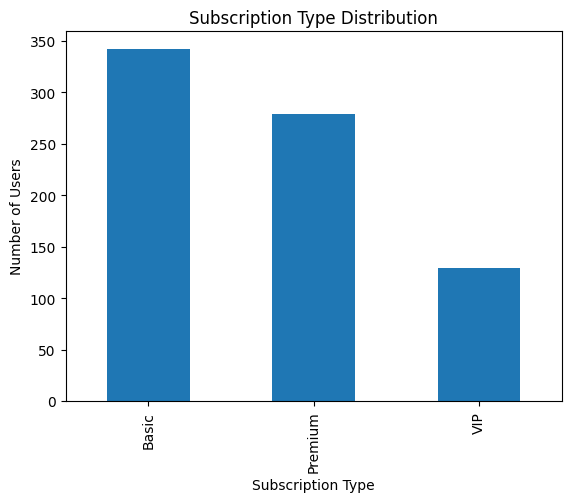

In [25]:
import matplotlib.pyplot as plt

df['SubscriptionType'].value_counts().plot(kind='bar')

plt.title("Subscription Type Distribution")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")
plt.show()

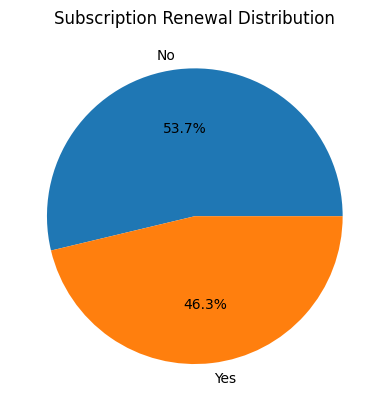

In [26]:
df['SubscriptionRenewed'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Subscription Renewal Distribution")
plt.ylabel("")
plt.show()

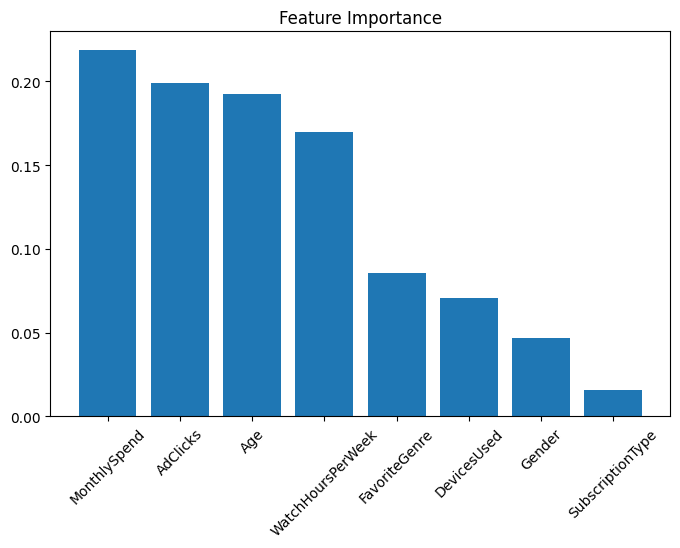

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [28]:
# Business Related Questions

1. Which factors appear to influence subscription renewal the most?

Based on the Decision Tree feature importance analysis, the most influential factors are:

MonthlySpend
AdClicks
Age
WatchHoursPerWeek
FavoriteGenre

Users who spend more, watch content regularly, and engage more with the platform are generally more likely to renew their subscriptions.

2. Why is subscription renewal a classification problem?

Subscription renewal is a classification problem because the target variable has only two possible categories:

Yes (Renewed)
No (Not Renewed)

The model predicts which category a user belongs to rather than predicting a numerical value.

3. Why is monthly spending a regression problem?

Monthly spending is a regression problem because the target variable is a continuous numerical value.

Examples:

₹350
₹700
₹1200

Since the model predicts a quantity rather than a category, regression algorithms are used.

4. Which algorithm performed better for renewal prediction?

After evaluating both models:

Decision Tree Accuracy = 56.00%
KNN Accuracy = 63.33%

Therefore, K-Nearest Neighbors (KNN) performed better on this dataset because it achieved higher prediction accuracy.

5. How could the platform use these predictions to improve customer retention?

Netflix can use these predictions to:

Identify users who are likely to cancel their subscriptions.
Provide personalized discounts and promotional offers.
Recommend content based on users' favorite genres.
Send engagement reminders and notifications.
Improve customer experience through targeted marketing campaigns.

These strategies can help increase customer satisfaction, reduce churn, and improve overall revenue.